# Run Variance Scripts, Bootstrap, and Plot

This notebook demonstrates the recommended reproduction workflow:

1. Call `reproduce/scripts/run_variance.py` to generate typical and atypical data.
2. Load the generated `.npy` files.
3. Bootstrap confidence intervals for the variance of the rescaled squared error.
4. Plot entanglement entropy and variance.

The default settings use `n=10`, `depth=40`, and `samples=2000`.

## Parameters

In [ ]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "reproduce" / "scripts" / "run_variance.py").exists():
    if REPO_ROOT == REPO_ROOT.parent:
        raise RuntimeError("Could not locate repository root")
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from reproduce.src.bootstrap import bootstrap_ci

N = 10
DEPTH = 40
SAMPLES = 2000
DELTA_T = 0.01
ORDER = 1

TYPICAL_SEED = 1234
ATYPICAL_SEED = 5678
BOOTSTRAP_SAMPLES = 10000
BOOTSTRAP_SEED = 2468

OUTPUT_ROOT = REPO_ROOT / "reproduce" / "outputs" / "run_variance_then_plot"
TYPICAL_DIR = OUTPUT_ROOT / "typical"
ATYPICAL_DIR = OUTPUT_ROOT / "atypical"
FIGURE_DIR = OUTPUT_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

%cd $REPO_ROOT


/home/xrzhang/Quantum-Resource-and-Quantum-Simulation


## Generate Data by Calling `run_variance.py`

These cells directly call the cleaned command-line script. They write new data under `reproduce/outputs/run_variance_then_plot/` and do not overwrite the original data directories.

In [2]:
%run reproduce/scripts/run_variance.py --case typical --n $N --depth $DEPTH --samples $SAMPLES --delta-t $DELTA_T --seed $TYPICAL_SEED --output-dir $TYPICAL_DIR


Saved results to /home/xrzhang/Quantum-Resource-and-Quantum-Simulation/reproduce/outputs/run_variance_then_plot/typical


In [4]:
%run reproduce/scripts/run_variance.py --case atypical --n $N --depth $DEPTH --samples $SAMPLES --delta-t $DELTA_T --seed $ATYPICAL_SEED --output-dir $ATYPICAL_DIR 


Saved results to /home/xrzhang/Quantum-Resource-and-Quantum-Simulation/reproduce/outputs/run_variance_then_plot/atypical


## Inspect Generated Files

In [5]:
print("Typical files:")
for path in sorted(TYPICAL_DIR.glob("*.npy"))[:10]:
    print(" ", path.name)
print("...")

print("Atypical files:")
for path in sorted(ATYPICAL_DIR.glob("*.npy"))[:10]:
    print(" ", path.name)
print("...")


Typical files:
  ent_0.npy
  ent_1.npy
  ent_10.npy
  ent_11.npy
  ent_12.npy
  ent_13.npy
  ent_14.npy
  ent_15.npy
  ent_16.npy
  ent_17.npy
...
Atypical files:
  antient_0.npy
  antient_1.npy
  antient_10.npy
  antient_11.npy
  antient_12.npy
  antient_13.npy
  antient_14.npy
  antient_15.npy
  antient_16.npy
  antient_17.npy
...


## Bootstrap Variance Confidence Intervals

The generic bootstrap routine lives in `reproduce/src/bootstrap.py`. In this notebook, the only statistic we define for each bootstrap sample is the variance.

In [ ]:
def variance_statistic(sample):
    return np.var(sample)


def load_variance_series(data_dir, prefix, depth, bootstrap_samples, seed):
    rng = np.random.default_rng(seed)
    variances = np.empty(depth + 1)
    yerr = np.zeros((2, depth + 1))
    for index in range(depth + 1):
        errors = np.load(data_dir / f"{prefix}_{index}.npy")
        scaled_errors = (errors/(DELTA_T**(ORDER+1)))**2
        variance, lower_err, upper_err = bootstrap_ci(
            scaled_errors,
            statistic=variance_statistic,
            n_resamples=bootstrap_samples,
            rng=rng,
        )
        variances[index] = variance
        yerr[0, index] = upper_err
        yerr[1, index] = lower_err
    return variances, yerr


In [7]:
typical_variance, typical_yerr = load_variance_series(
    TYPICAL_DIR,
    prefix="ent",
    depth=DEPTH,
    bootstrap_samples=BOOTSTRAP_SAMPLES,
    seed=BOOTSTRAP_SEED,
)

atypical_variance, atypical_yerr = load_variance_series(
    ATYPICAL_DIR,
    prefix="antient",
    depth=DEPTH,
    bootstrap_samples=BOOTSTRAP_SAMPLES,
    seed=BOOTSTRAP_SEED + 1,
)


## Plot Entanglement and Variance

PosixPath('/home/xrzhang/Quantum-Resource-and-Quantum-Simulation/reproduce/outputs/run_variance_then_plot/figures/variance_bootstrap_example.pdf')

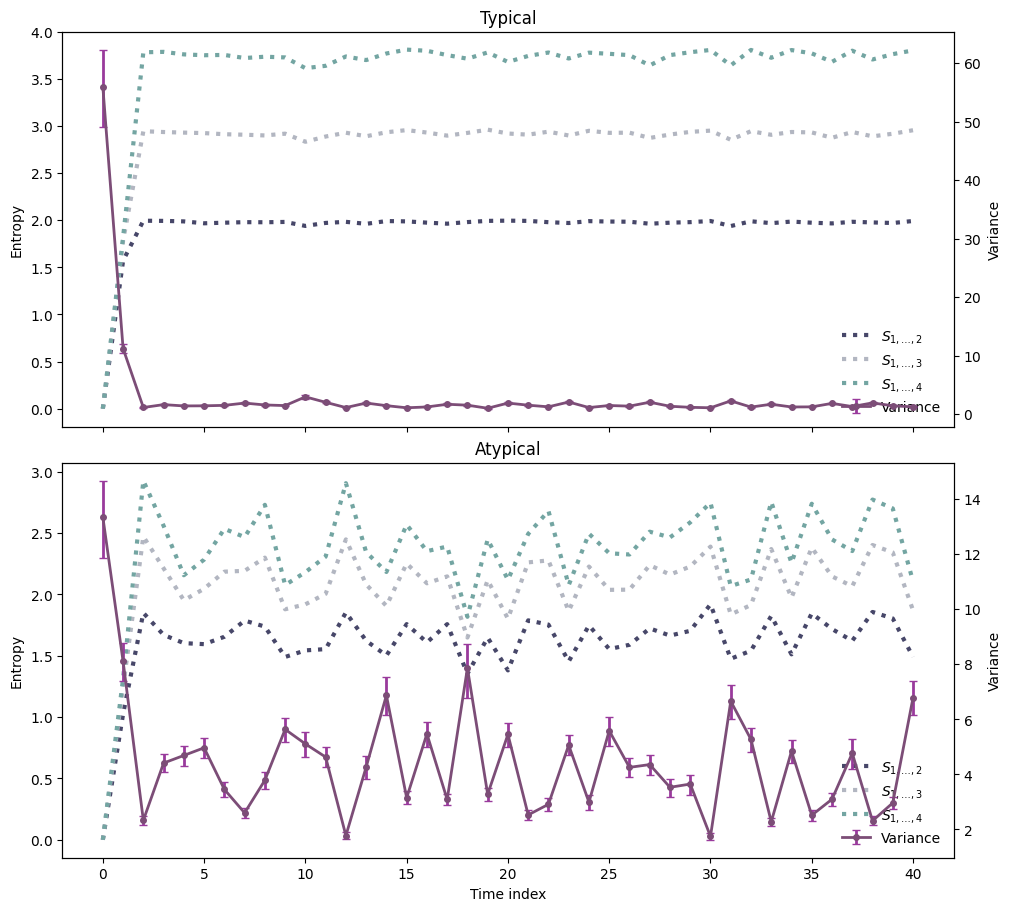

In [8]:
times = np.arange(DEPTH + 1)
colors = {
    "variance": "#7C4D77",
    "ci": "#993A9C",
    2: "#474769",
    3: "#B2B6C1",
    4: "#73A5A2",
}

fig, (ax_typical, ax_atypical) = plt.subplots(
    2,
    1,
    figsize=(10, 9),
    sharex=True,
    layout="constrained",
)

plot_cases = [
    ("Typical", ax_typical, TYPICAL_DIR, "typical", typical_variance, typical_yerr),
    ("Atypical", ax_atypical, ATYPICAL_DIR, "atypical", atypical_variance, atypical_yerr),
]

for title, ax_entropy, data_dir, case_name, variances, yerr in plot_cases:
    ax_entropy.set_title(title)
    ax_entropy.set_ylabel("Entropy")
    for subsystem_size in (2, 3, 4):
        entropy_values = np.load(data_dir / f"part{subsystem_size}{case_name}.npy")
        ax_entropy.plot(
            times,
            entropy_values,
            linestyle="dotted",
            linewidth=3,
            color=colors[subsystem_size],
            label=rf"$S_{{1,\ldots,{subsystem_size}}}$",
        )
    ax_entropy.ticklabel_format(style="sci", axis="y", scilimits=(-2, 2), useMathText=True)

    ax_variance = ax_entropy.twinx()
    ax_variance.set_ylabel("Variance")
    ax_variance.errorbar(
        times,
        variances,
        yerr=yerr,
        fmt="o",
        linestyle="-",
        linewidth=2,
        markersize=4,
        color=colors["variance"],
        ecolor=colors["ci"],
        capsize=3,
        label="Variance",
    )
    ax_variance.ticklabel_format(style="sci", axis="y", scilimits=(-2, 2), useMathText=True)

    h1, l1 = ax_entropy.get_legend_handles_labels()
    h2, l2 = ax_variance.get_legend_handles_labels()
    ax_entropy.legend(h1 + h2, l1 + l2, loc="best", framealpha=0)

ax_atypical.set_xlabel("Time index")
figure_path = FIGURE_DIR / "variance_bootstrap_example.pdf"
plt.savefig(figure_path, bbox_inches="tight", pad_inches=0.1, dpi=200, transparent=True)
figure_path
